## Import Libraries

In [15]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
from time import time

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
 )
from sklearn.utils.class_weight import compute_class_weight

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('Set2')

# Compatibility flag used in summary cell
IMBALANCED_LEARN_AVAILABLE = True

## Load Preprocessed Data

In [16]:
df = pd.read_csv('../data/data_features_engineering.csv')

In [17]:
target_col = 'income_target'

X = df.drop(columns=[target_col])
y = df[target_col]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
    shuffle=True,
 )

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')

Training set: (36155, 113)
Test set: (9039, 113)
Features: 113


In [19]:
class_dist = y_train.value_counts(normalize=True) * 100
print('\nClass distribution in training set:')
for value, pct in class_dist.items():
    label = '>$50K' if value == 1 else '<=$50K'
    print(f'  {label} ({value}): {pct:.1f}%')


Class distribution in training set:
  <=$50K (0): 75.2%
  >$50K (1): 24.8%


In [20]:
# Calculate class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print(f'\nClass weights for balancing: {class_weight_dict}')


Class weights for balancing: {0: 0.6648584038249357, 1: 2.0164528722810933}


## Define Models to Train

In [21]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,
        max_depth=12,
        min_samples_split=10
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=9,
        weights='distance'
    )
}

print('Models to train:')
for model_name in models:
    print(f'- {model_name}')

Models to train:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors


## Cross-Validation Training and Evaluation

In [22]:
# Setup cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_results = []
trained_models = {}
all_predictions = {}

for model_name, current_model in models.items():
    print(f'\nTraining {model_name}...')

    cv_scores = cross_val_score(current_model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_auc = cross_val_score(current_model, X_train, y_train, cv=cv, scoring='roc_auc')

    current_model.fit(X_train, y_train)
    y_pred = current_model.predict(X_test)

    if hasattr(current_model, 'predict_proba'):
        y_pred_proba = current_model.predict_proba(X_test)[:, 1]
    else:
        # Fallback for models without predict_proba support
        y_pred_proba = current_model.predict(X_test)

    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)

    model_results.append({
        'Model': model_name,
        'CV Accuracy Mean': cv_scores.mean(),
        'CV Accuracy Std': cv_scores.std(),
        'CV AUC Mean': cv_auc.mean(),
        'CV AUC Std': cv_auc.std(),
        'Test Accuracy': test_accuracy,
        'Test Precision': test_precision,
        'Test Recall': test_recall,
        'Test F1': test_f1,
        'Test AUC': test_auc,
    })

    trained_models[model_name] = current_model
    all_predictions[model_name] = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'cm': confusion_matrix(y_test, y_pred),
    }

results_df = pd.DataFrame(model_results).sort_values(by='Test AUC', ascending=False).reset_index(drop=True)
best_model_name = results_df.loc[0, 'Model']
model = trained_models[best_model_name]
y_pred = all_predictions[best_model_name]['y_pred']
y_pred_proba = all_predictions[best_model_name]['y_pred_proba']
cm = all_predictions[best_model_name]['cm']

print('\nModel comparison (sorted by Test AUC):')
display(results_df)
print(f'\nBest model selected: {best_model_name}')


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training K-Nearest Neighbors...

Model comparison (sorted by Test AUC):


,Model,CV Accuracy Mean,CV Accuracy Std,CV AUC Mean,CV AUC Std,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,Logistic Regression,0.812834,0.002412,0.911899,0.004264,0.808386,0.577805,0.843373,0.685776,0.907809
1,Random Forest,0.841433,0.002341,0.895708,0.003602,0.843124,0.695487,0.653280,0.673723,0.892730
2,Decision Tree,0.800028,0.006096,0.882950,0.008043,0.797655,0.559538,0.863900,0.679179,0.888906
3,K-Nearest Neighbors,0.828986,0.002894,0.858339,0.004507,0.829959,0.677778,0.598840,0.635868,0.857115



Best model selected: Logistic Regression


In [23]:
print(f'Classification report for best model: {best_model_name}')
print(classification_report(y_test, y_pred))

Classification report for best model: Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.80      0.86      6798
           1       0.58      0.84      0.69      2241

    accuracy                           0.81      9039
   macro avg       0.76      0.82      0.77      9039
weighted avg       0.85      0.81      0.82      9039



In [24]:
# Best-model metrics (already computed in training loop and selected above)
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba)

best_row = results_df.loc[results_df['Model'] == best_model_name].iloc[0]
print(f'Best Model: {best_model_name}')
print(f"CV Accuracy: {best_row['CV Accuracy Mean']:.4f} +- {best_row['CV Accuracy Std']:.4f}")
print(f"CV AUC: {best_row['CV AUC Mean']:.4f} +- {best_row['CV AUC Std']:.4f}")
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test Recall: {test_recall:.4f}')
print(f'Test F1: {test_f1:.4f}')
print(f'Test AUC: {test_auc:.4f}')

print('\nAll models summary:')
display(results_df[['Model', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test AUC']])

Best Model: Logistic Regression
CV Accuracy: 0.8128 +- 0.0024
CV AUC: 0.9119 +- 0.0043
Test Accuracy: 0.8084
Test Precision: 0.5778
Test Recall: 0.8434
Test F1: 0.6858
Test AUC: 0.9078

All models summary:


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,Logistic Regression,0.808386,0.577805,0.843373,0.685776,0.907809
1,Random Forest,0.843124,0.695487,0.653280,0.673723,0.892730
2,Decision Tree,0.797655,0.559538,0.863900,0.679179,0.888906
3,K-Nearest Neighbors,0.829959,0.677778,0.598840,0.635868,0.857115


## Visualize Model Performance

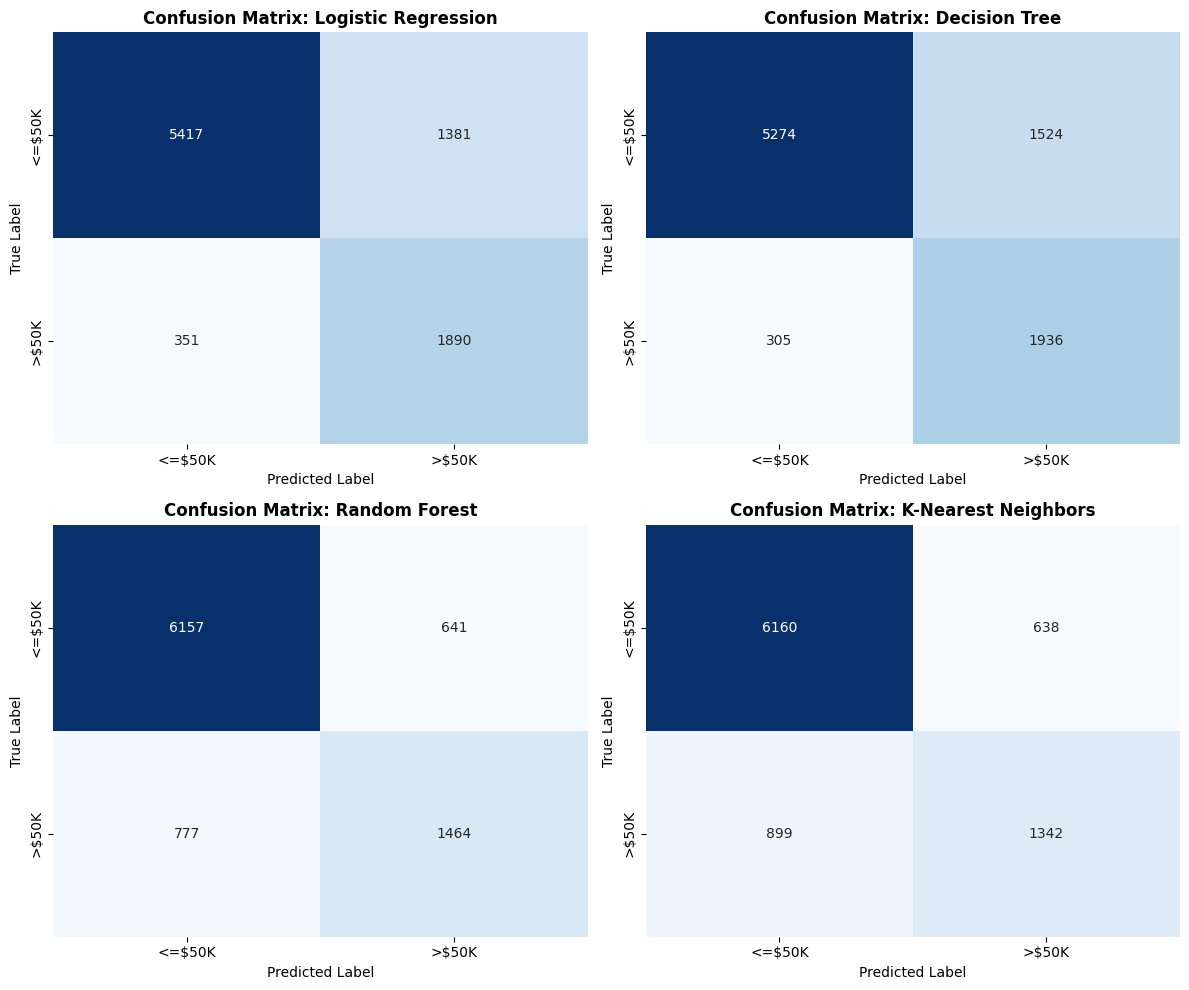

Best model selected: Logistic Regression


In [29]:
# 1) Confusion matrices for all trained models
n_models = len(all_predictions)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, (model_name, pred_info) in enumerate(all_predictions.items()):
    cm_model = pred_info['cm']
    sns.heatmap(
        cm_model,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['<=$50K', '>$50K'],
        yticklabels=['<=$50K', '>$50K'],
        ax=axes[i],
    )
    axes[i].set_title(f'Confusion Matrix: {model_name}', fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

# Hide any unused subplot axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print(f'Best model selected: {best_model_name}')

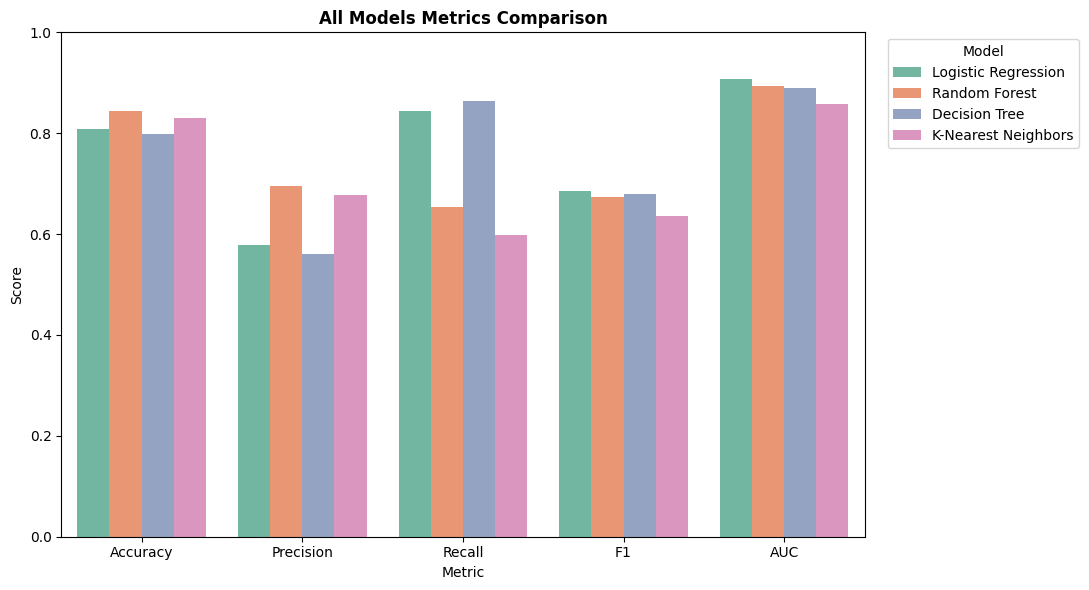

Best model selected: Logistic Regression


In [30]:
# 2) Metrics comparison chart for all models
metric_columns = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test AUC']
metrics_long = results_df[['Model'] + metric_columns].melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score',
)
metrics_long['Metric'] = metrics_long['Metric'].str.replace('Test ', '', regex=False)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=metrics_long,
    x='Metric',
    y='Score',
    hue='Model',
    hue_order=results_df['Model'].tolist(),
)
ax.set_ylim(0, 1)
ax.set_title('All Models Metrics Comparison', fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Metric')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f'Best model selected: {best_model_name}')

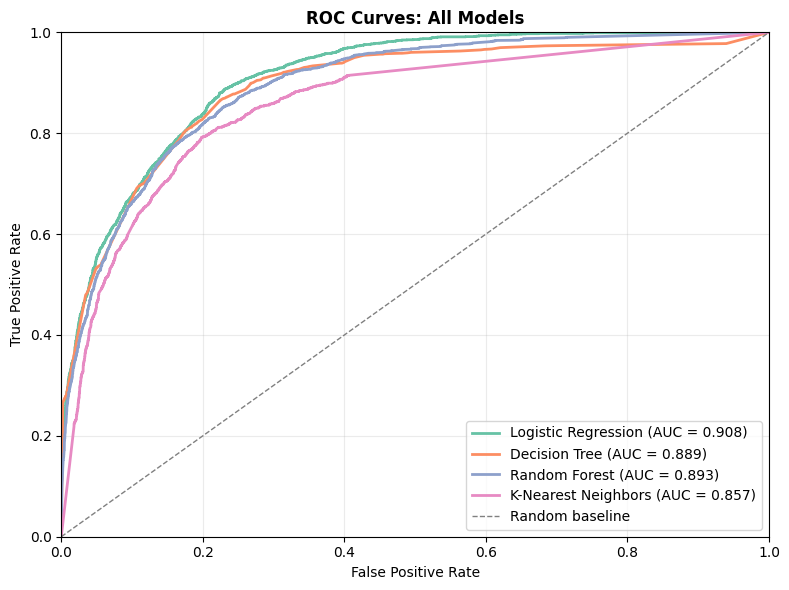

Best model selected: Logistic Regression


In [31]:
# 3) ROC curves for all trained models
plt.figure(figsize=(8, 6))

for model_name, pred_info in all_predictions.items():
    y_proba_model = pred_info['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba_model)
    auc_model = roc_auc_score(y_test, y_proba_model)
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc_model:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random baseline')
plt.title('ROC Curves: All Models', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f'Best model selected: {best_model_name}')

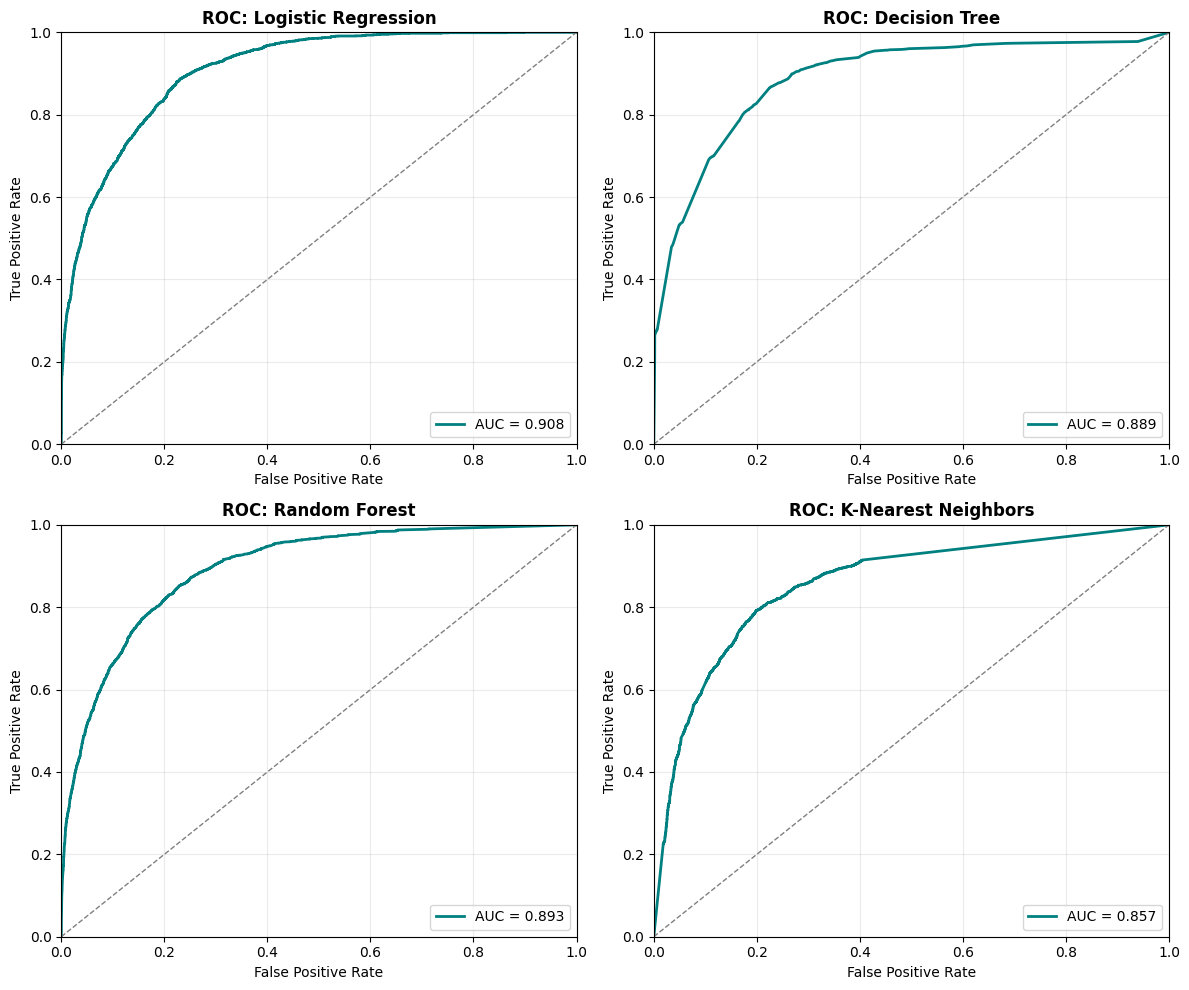

Best model selected: Logistic Regression


In [33]:
# 4) ROC subplots (one panel per model)
n_models = len(all_predictions)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, (model_name, pred_info) in enumerate(all_predictions.items()):
    y_proba_model = pred_info['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba_model)
    auc_model = roc_auc_score(y_test, y_proba_model)

    axes[i].plot(fpr, tpr, linewidth=2, color='teal', label=f'AUC = {auc_model:.3f}')
    axes[i].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    axes[i].set_title(f'ROC: {model_name}', fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].grid(alpha=0.25)
    axes[i].legend(loc='lower right')

# Hide any unused subplot axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print(f'Best model selected: {best_model_name}')

## Save a model

In [32]:
from pathlib import Path

# Prepare output directory
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

saved_model_paths = []
saved_metadata_paths = []

# Save every trained model with its own metadata
for model_name, trained_model in trained_models.items():
    safe_model_name = model_name.lower().replace(' ', '_').replace('-', '_')
    model_path = models_dir / f'{safe_model_name}_model.pkl'
    metadata_path = models_dir / f'{safe_model_name}_metadata.json'

    # Save model file
    joblib.dump(trained_model, model_path)

    # Grab metrics row for this model
    model_row = results_df.loc[results_df['Model'] == model_name].iloc[0]
    model_cm = all_predictions[model_name]['cm']

    model_metadata = {
        'model_name': model_name,
        'model_type': type(trained_model).__name__,
        'features_used': X_train.columns.tolist() if 'X_train' in globals() else [],
        'training_samples': int(len(X_train)) if 'X_train' in globals() else None,
        'test_samples': int(len(X_test)) if 'X_test' in globals() else None,
        'cv_accuracy_mean': float(model_row['CV Accuracy Mean']),
        'cv_accuracy_std': float(model_row['CV Accuracy Std']),
        'cv_auc_mean': float(model_row['CV AUC Mean']),
        'cv_auc_std': float(model_row['CV AUC Std']),
        'test_accuracy': float(model_row['Test Accuracy']),
        'test_precision': float(model_row['Test Precision']),
        'test_recall': float(model_row['Test Recall']),
        'test_f1': float(model_row['Test F1']),
        'test_auc': float(model_row['Test AUC']),
        'confusion_matrix': model_cm.tolist(),
        'is_best_model': bool(model_name == best_model_name),
    }

    with open(metadata_path, 'w', encoding='utf-8') as f:
        json.dump(model_metadata, f, indent=2)

    saved_model_paths.append(str(model_path))
    saved_metadata_paths.append(str(metadata_path))

# Optional run-level summary across all models
run_summary_path = models_dir / 'all_models_run_summary.json'
run_summary = {
    'best_model_name': best_model_name,
    'saved_model_files': saved_model_paths,
    'saved_metadata_files': saved_metadata_paths,
    'all_models_results': results_df.to_dict(orient='records'),
}
with open(run_summary_path, 'w', encoding='utf-8') as f:
    json.dump(run_summary, f, indent=2)

print('Saved model files:')
for p in saved_model_paths:
    print(f'- {p}')

print('\nSaved metadata files:')
for p in saved_metadata_paths:
    print(f'- {p}')

print(f'\nRun summary saved to: {run_summary_path}')
print(f'Best model selected in this run: {best_model_name}')

Saved model files:
- ../models/logistic_regression_model.pkl
- ../models/decision_tree_model.pkl
- ../models/random_forest_model.pkl
- ../models/k_nearest_neighbors_model.pkl

Saved metadata files:
- ../models/logistic_regression_metadata.json
- ../models/decision_tree_metadata.json
- ../models/random_forest_metadata.json
- ../models/k_nearest_neighbors_metadata.json

Run summary saved to: ../models/all_models_run_summary.json
Best model selected in this run: Logistic Regression
